In [3]:
import h5py
import helpers
import numpy as np
from pathlib import Path
import torch
from torch.utils import data

import os.path as osp
import os

import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2


import cloudpickle as pickle

def save_obj(obj, name):
    with open(name + '.pkl', 'wb') as f:
        pickle.dump(obj, f)
        
def load_obj(name):
    with open(name, 'rb') as f:
        return pickle.load(f)



In [4]:
history = load_obj("default_lr_12_11_2_train_history_inprog.pkl")

In [5]:
history

{'train_loss': [-2.9122780749152377,
  -3.0523481968358075,
  -3.129885734774131,
  -3.1516163632356,
  -3.162228921500359,
  -3.1700068238031798,
  -3.179239307319262,
  -3.188093722195915,
  -3.19414814796237,
  -3.2006777287846773,
  -3.21041109021856,
  -3.2140948370675355,
  -3.2186569732855697,
  -3.224211780405835,
  -3.230108793269205,
  -3.232472205030325,
  -3.234124877834847,
  -3.2388506403285495,
  -3.2360440295045545,
  -3.2417252775055267],
 'val_loss': [-3.0847015267326716,
  -3.099689009643736,
  -3.125642398993174,
  -3.1359441649346125,
  -3.1509616800716946,
  -3.1605031206494285,
  -3.1675756119546437,
  -3.1718185657546636,
  -3.186479003656478,
  -3.1893409320286343,
  -3.2005012716565813,
  -3.2008375497091386,
  -3.2080926469394138,
  -3.214654811791011,
  -3.213698937779381,
  -3.212476372718811,
  -3.2193593184153237,
  -3.2194544076919556,
  -3.224549040907905,
  -3.227834653286707],
 'test_loss': [],
 'losses': []}

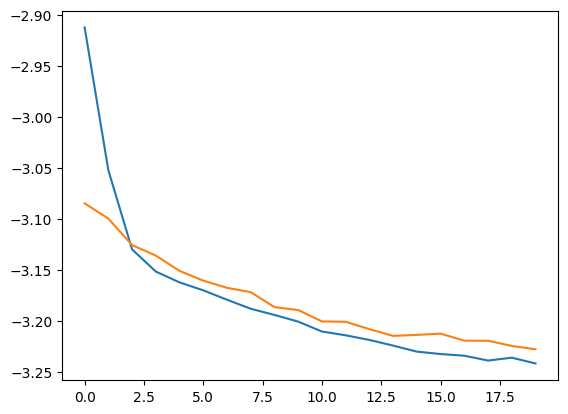

In [6]:
plt.plot(history['train_loss'])
plt.plot(history['val_loss'])

In [7]:
N_FG

NameError: name 'N_FG' is not defined

## now load the model and do the second moment

In [16]:
import h5py
import helpers
import numpy as np
from pathlib import Path
import torch
from torch.utils import data
from torch.utils.data.dataloader import default_collate

import gc
from accelerate import Accelerator

import os.path as osp
import os

import cloudpickle as pickle
import sys,os,json

from dataloader import *
from nets import *
from nets2_attn import *

# --------------------------------------------------------------------------------------

def save_obj(obj, name):
    with open(name + '.pkl', 'wb') as f:
        pickle.dump(obj, f)
        
def load_obj(name):
    with open(name, 'rb') as f:
        return pickle.load(f)
    

# --------------------------------------------------------------------------------------
# custom log-mse loss


def transform_inputs(inputs, scaling=1e5):
    inputs *= scaling
    #inputs += 10.0
    #inputs += 1e-3
    return torch.arcsinh(inputs)

def inv_transform_inputs(inputs, scaling=1e5):
    inputs = torch.sinh(inputs)
    #inputs -= 7.0
    #inputs -= 1e-3
    inputs /= scaling
    return inputs


# --------------------------------------------------------------------------------------


### READ IN CONFIGS
config_file_path = "./configs_default2.json" #sys.argv[1] #'./comparison/configs.json'


with open(config_file_path) as f:
        configs = json.load(f)


# model stuff
# HIDDEN_CHANNELS = configs["model_params"][model_type][model_size]["hidden_channels"]
# NUM_LAYERS = configs["model_params"][model_type][model_size]["num_layers"]
# MODEL_NAME = configs["model_params"][model_type][model_size]["name"]
# TEST_BATCHING = configs["model_params"][model_type][model_size]["test_batching"]
        
FILTERS = configs["model_params"]["filters"]
NOISEAMP = configs["model_params"]["noiseamp"]
N_FG = configs["model_params"]["n_fg"]
MODEL_PATH = configs["model_params"]["model_path"]
MODEL_NAME = configs["model_params"]["model_name"]



# # optimizer schedule
LEARNING_RATE = configs["training_params"]["learning_rate"]
BATCH_SIZE = configs["training_params"]["batch_size"]
EPOCHS = int(configs["training_params"]["epochs"])
#DO_SCHEDULER = bool(int(configs["training_params"]["do_lr_scheduler"]))
SEED = int(configs["training_params"]["seed"])

# # data + out directories
cosmopath = configs["training_params"]["cosmopath"]
galpath = configs["training_params"]["galpath"]


MODEL_DIR = configs["model_params"]["model_dir"]
LOAD_DIR = configs["model_params"]["load_dir"]
LOAD_MODEL = bool(configs["training_params"]["load_model"])

TRAIN_WITH_CACHE = False
ADD_NOISE = configs["training_params"]["add_noise"]


if not os.path.exists(MODEL_DIR):
   # Create a new directory if it does not exist
   os.makedirs(MODEL_DIR)
   print("created new directory", MODEL_DIR)

# ### CONSTRUCT MODEL NAME AND OUTPUT PATH
# MODEL_NAME += "nc_%d_nlyr_%d"%(HIDDEN_CHANNELS, NUM_LAYERS)
# MODEL_PATH = MODEL_DIR + MODEL_NAME
# LOAD_PATH = LOAD_DIR + MODEL_NAME



# --------------------------------------------------------------------------------------
    
print("LOADING DATA AND INITIALISING DATALOADERS")

# fix random seed
np.random.seed(SEED)
torch.manual_seed(SEED)

# set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

cosmofiles = os.listdir(cosmopath)
galfiles = os.listdir(galpath)

# save the filenames 
#save_obj(cosmofiles, "/data101/makinen/hirax_sims/dataloader/cosmofiles")
#save_obj(galfiles, "/data101/makinen/hirax_sims/dataloader/galfile")


cosmofiles = [cosmopath + p for p in cosmofiles]
galfiles =  [galpath + p for p in galfiles]


# random mask for train/val split
mask = np.random.rand(len(cosmofiles)) < 0.9
train_cosmo_files = list(np.array(cosmofiles)[mask])[:configs["training_params"]["num_train"]]
val_cosmo_files = list(np.array(cosmofiles)[~mask])

galmask = np.random.rand(len(galfiles)) < 0.9
train_gal_files = list(np.array(galfiles)[galmask])
val_gal_files = list(np.array(galfiles)[~galmask])

# --------------------------------------------------------------------------------------




def preprocess_data(x,y):
    
        # split ordering (batch, baseline, freq, ra) = (batch*split, 48, 128, 128)
        # then transpose to (batch*split, freq, ra, baseline)
        x = torch.permute(
            torch.cat(torch.tensor_split(x, split, dim=3)),
            (0, 3, 1, 2)
        )
        y = torch.permute(
                torch.cat(torch.tensor_split(y, split, dim=3)),
                (0, 3, 1, 2)
        )
        # then finally get the real and im parts as channels
        # shape: (batch*split, freq, ra, baseline, Re/Im)
        x = torch.stack([x.real, x.imag], dim=-1)
        y = torch.stack([y.real, y.imag], dim=-1)
        
        x *= 1e5
        y *= 1e5

        
        # add white noise to the signal
        if ADD_NOISE:
            x += torch.normal(mean=0.0, std=torch.ones(x.shape)*NOISEAMP) #.to(device)
        
        # pass x to the pca
        x = PCALayer(x, N_FG=N_FG)
        
        # log-transformation of input data for network
        #x = transform_inputs(x, scaling=1e5)
        
        # transformation of outputs handled in the loss function
        #y = transform_inputs(y, scaling=1e5)

        
        # get y into same shape as model outputs
        y = torch.permute(y, (0, 4, 2, 1, 3))
        
        return x.to(device),y.to(device)
    

def my_collate_fn(batch):
    print("batch", len(batch))
    x,y = batch
    x,y = preprocess_data(x,y)
    return x.to(device), y.to(device)


# --------------------------------------------------------------------------------------


# create train and val datasets and loaders with collate fn

print("INITIALISING dataloaders")
train_dataset = H5Dataset(train_cosmo_files, train_gal_files, use_cache=False)
val_dataset = H5Dataset(val_cosmo_files, val_gal_files, use_cache=False)


train_dataloader = DataLoader(
    train_dataset,
    batch_size=2,  # bigger batch ?
    num_workers=1, # how high can we go ?
    shuffle=False,
    pin_memory=True, # do we need this ?
    #collate_fn=my_collate_fn
)


val_dataloader = DataLoader(
    val_dataset,
    num_workers=0,
    shuffle=False,
    pin_memory=True
)


# --------------------------------------------------------------------------------------

# initialise model and accelerator


print("INITIALISING MODEL")



split = 1024 // 128 # 8 chunks per sky simulation


#STEPS_PER_EPOCH = 100 # reshuffle data each time 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

#block = BasicBlock(16, 32)
model = UNet3d(BasicBlock, filters=FILTERS).to(device)


#model = UNet3DWithAttention(in_channels=2, out_channels=2, init_features=FILTERS)


# # start up the optimizer
# optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
# criterion = logMSELoss()

# model_path = MODEL_PATH
# model_path += MODEL_NAME
# accelerator = Accelerator(project_dir=model_path)

# model, optimizer, train_dataloader = accelerator.prepare(
#                 model, optimizer, train_dataloader)



# if LOAD_MODEL:
#     model.load_state_dict(torch.load(MODEL_PATH))
#     model.eval()
#     history = load_obj(MODEL_DIR + MODEL_NAME + "history.pkl")


LOADING DATA AND INITIALISING DATALOADERS
INITIALISING dataloaders
INITIALISING MODEL


In [282]:
ADD_NOISE

0

In [9]:
model.load_state_dict(torch.load(MODEL_PATH + "default_lr_12_11_2/pytorch_model.bin"))

<All keys matched successfully>

In [10]:
MODEL_PATH

'/data101/makinen/hirax_sims/accelerator/'

## plotting stuff

In [17]:
#from plot_metrics import *

from astropy.cosmology import FlatLambdaCDM
from astropy import units
from astropy import constants as consts
import numpy as np

from scipy.signal.windows import blackmanharris
import matplotlib.pyplot as plt

cosmology = FlatLambdaCDM(H0=100, Om0=0.3) # H0=100 km/s/Mpc so in h units
nu_21 = 1420.405751768*units.MHz

def z21(freq):
    freq = units.Quantity(freq, unit=units.MHz)
    return (nu_21/freq - 1).value

def k_perpendicular(bl_length, freq):
    freq = units.Quantity(freq, unit=units.MHz)
    bl_length = units.Quantity(bl_length, unit=units.m)
    wl = freq.to('m', equivalencies=units.spectral())
    k_pp = 2*np.pi*np.linalg.norm(bl_length)/wl/cosmology.comoving_transverse_distance(z21(freq))
    return k_pp.to('Mpc^-1')

def delays_from_freqs(freqs):
    freqs = units.Quantity(freqs, unit=units.MHz)
    d = (freqs[1]-freqs[0]).to('ns^-1')
    return np.fft.fftshift(np.fft.fftfreq(len(freqs), d=d))

def k_parallel(delays, freq):
    freq = units.Quantity(freq, unit=units.MHz)
    z = z21(freq)
    eta_to_kh = 2*np.pi*nu_21*cosmology.H(z)/consts.c/(1+z)**2
    k_parallel = (eta_to_kh*delays).to('Mpc^-1')
    return k_parallel
    
def wedge(theta_0, bl_ind, band_center=550*units.MHz):
    
    z = z21(band_center)
    wl = band_center.to('m', equivalencies=units.spectral()).value
    
    bl = baselines[bl_ind, ...]*units.m
    
    k_pp = k_perpendicular(np.linalg.norm(bl), band_center)
    k_par = theta_0.to('rad').value*k_pp*((cosmology.H(z)*cosmology.comoving_transverse_distance(z))/(consts.c*(1+z))).to('').value
    
    return k_par*0.7 # Double check h factor

def baseline_delay_spectrum(data, bl_ind, band_center=550*units.MHz):
    
    #with h5py.File(vis_fname, 'r') as fil:
    #    data = fil['vis'][bl_ind, ...] # bl, freq, ras
    
    data = data[bl_ind]
        
    N = data.shape[0] # Number of freqs
    
    z = z21(band_center)
    eta_to_kh = 2*np.pi*nu_21*cosmology.H(z)/consts.c/(1+z)**2
    
    delays = delays_from_freqs(freqs)
    k_par = k_parallel(delays, band_center)
    window = blackmanharris(N)
    
    delay_spec = np.fft.fftshift(np.abs(np.fft.fft(data*window[:, None], axis=0))**2)*units.K**2
    
    return delays, k_par, delay_spec

def plot_delay_spectrum(data, bl_ind, band_center=550*units.MHz, wedge_angle=90*units.deg, rel_range=12):
    
    delays, k_par, delay_spec = baseline_delay_spectrum(data, bl_ind, band_center=band_center)
    
    ras = np.linspace(180, -180, delay_spec.shape[1] + 1)
    
    fig, ax = plt.subplots(figsize=(10, 4))
    
    extent = (ras[0], ras[-1], k_par[0].value, k_par[-1].value)
    
    to_plot = np.log10(delay_spec.value[:, ::-1])
    vmin = to_plot.max() - rel_range
    
    im = ax.imshow(to_plot, vmin=vmin, aspect=100, extent=extent, origin='lower', cmap='magma')
    
    wedge_k_pp = wedge(wedge_angle, bl_ind, band_center=band_center)
    ax.axhline(wedge_k_pp.value, color='white', ls='--')
    ax.axhline(-wedge_k_pp.value, color='white', ls='--')
    
    ax.set_xlabel('RA [deg]')
    ax.set_ylabel(r'$k_{\parallel}$ [h Mpc$^{-1}$]')
    
    plt.colorbar(im, label='[K$^2$]')
    
    return fig

def plot_delay_spectrum_of_residual(data1, data_true, bl_ind, band_center=550*units.MHz, wedge_angle=90*units.deg, rel_range=12):
    
    delays, k_par, delay_spec = baseline_delay_spectrum((data1 - data_true), bl_ind, band_center=band_center)
    
    delays, k_par, delay_spec2 = baseline_delay_spectrum((data_true), bl_ind, band_center=band_center)

    delay_spec /= delay_spec2
    
    
    ras = np.linspace(180, -180, delay_spec.shape[1] + 1)
    
    fig, ax = plt.subplots(figsize=(10, 4))
    
    extent = (ras[0], ras[-1], k_par[0].value, k_par[-1].value)
    
    to_plot = delay_spec.value[:, ::-1] #np.log10(delay_spec.value[:, ::-1])
    vmin = to_plot.max() - rel_range
    
    im = ax.imshow(to_plot, aspect=100, vmin=-2, vmax=2, extent=extent, origin='lower', cmap="coolwarm")
    
    wedge_k_pp = wedge(wedge_angle, bl_ind, band_center=band_center)
    ax.axhline(wedge_k_pp.value, color='white', ls='--')
    ax.axhline(-wedge_k_pp.value, color='white', ls='--')
    
    ax.set_xlabel('RA [deg]')
    ax.set_ylabel(r'$k_{\parallel}$ [h Mpc$^{-1}$]')
    
    plt.colorbar(im, label='error')
    
    return (fig,delay_spec)

def plot_residual_of_delay_spectrum(data1, data_true, bl_ind, band_center=550*units.MHz, wedge_angle=90*units.deg, rel_range=12):
    
    delays1, k_par, delay_spec1 = baseline_delay_spectrum(data1, bl_ind, band_center=band_center)
    
    delays2, k_par, delay_spec2 = baseline_delay_spectrum(data_true, bl_ind, band_center=band_center)
    
    delay_spec = (delay_spec1 - delay_spec2) / delay_spec2
    
    ras = np.linspace(180, -180, delay_spec.shape[1] + 1)
    
    fig, ax = plt.subplots(figsize=(10, 4))
    
    extent = (ras[0], ras[-1], k_par[0].value, k_par[-1].value)
    
    #to_plot = np.log10(delay_spec.value[:, ::-1])
    to_plot = delay_spec.value[:, ::-1]
    vmin = to_plot.max() - rel_range
    
    im = ax.imshow(to_plot, aspect=100, vmin=-2, vmax=2, extent=extent, origin='lower', cmap="coolwarm")
    
    wedge_k_pp = wedge(wedge_angle, bl_ind, band_center=band_center)
    ax.axhline(wedge_k_pp.value, color='white', ls='--')
    ax.axhline(-wedge_k_pp.value, color='white', ls='--')
    
    ax.set_xlabel('RA [deg]')
    ax.set_ylabel(r'$k_{\parallel}$ [h Mpc$^{-1}$]')
    
    plt.colorbar(im, label='error')
    
    return (fig,delay_spec)

In [286]:
cosmo.real.min() * 1e5

-3.174180892528966

In [18]:
gpath = "/data101/makinen/hirax_sims/more_baselines/galaxy_gaussian_pb/"
cpath = "/data101/makinen/hirax_sims/cosmo_test_set/"
(xtest, ytest), testcosmo = val_dataset.load_sim_and_cosmology(cosmo_path = cpath + "cosmo_H0_pl18_vis_90.h5" , 
                                   gal_path = gpath + "galaxy_gsm_vis_81.h5")

#xtest = xtest[None, ...]
#ytest = ytest[None, ...]

In [19]:
ytest.real.min() * 1e5

tensor(-3.5568)

In [20]:
xtest.shape, ytest.shape

(torch.Size([1, 48, 128, 1024]), torch.Size([1, 48, 128, 1024]))

In [21]:
# apply network to the test simulation

def apply_network(x, y):
    
    x,y = preprocess_data(x.to(device),y.to(device))
    
    x = x.to(device)
    y = y.to(device)
    m = model.to(device)
    
    # inverse-transform taken care of
    #x = transform_inputs(x)
    preds = m(x, train=True).cpu()
    #preds = inv_transform_inputs(preds)
    #x = inv_transform_inputs(x)

    #print(m(x).cpu().sum())

    y = (y).cpu().detach().numpy()
    preds = (preds).detach().numpy()
    x = x.cpu().detach().numpy()
    
    return x,y,preds

In [22]:
x, y, preds = apply_network(xtest, ytest)

In [30]:
# load in a data vector
test_cosmo = h5py.File("/data101/makinen/hirax_sims/cosmo_gaussian_pb/cosmo_H0_60p894_vis_0.h5")
baselines = np.array(test_cosmo['/index_map/baselines/'])

# split ordering (batch, baseline, freq, ra) = (batch*split, 48, 128, 128)
# then transpose to (batch*split, freq, ra, baseline)

preds.shape, y.shape

# inputs to delay spectrum code need to be rearranged to
# (baseline, freq, ra)

num_base = 48
num_freq = 128

pca_pred = x.transpose((2, 4, 0, 3, 1)).reshape(48, num_freq, -1, 2) #/ 1e5
net_pred = preds.transpose((2, 4, 0, 3, 1)).reshape(48, num_freq, -1, 2) #/ 1e5
cosmo = y.transpose((2, 4, 0, 3, 1)).reshape(48, num_freq, -1, 2) #/ 1e5


pca_pred = pca_pred[..., 0] + pca_pred[..., 1]*1j
net_pred = net_pred[..., 0] + net_pred[..., 1]*1j
cosmo = cosmo[..., 0] + cosmo[..., 1]*1j

/tmp/ipykernel_135467/1654540769.py:3: DeprecationWarning: `product` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `prod` instead.
  baselines = np.array(test_cosmo['/index_map/baselines/'])


In [31]:
ibase = 9
freq_edges=np.linspace(500, 600, 128 + 1)
freqs = freq_edges[:-1] + np.diff(freq_edges[:2])[0] / 2

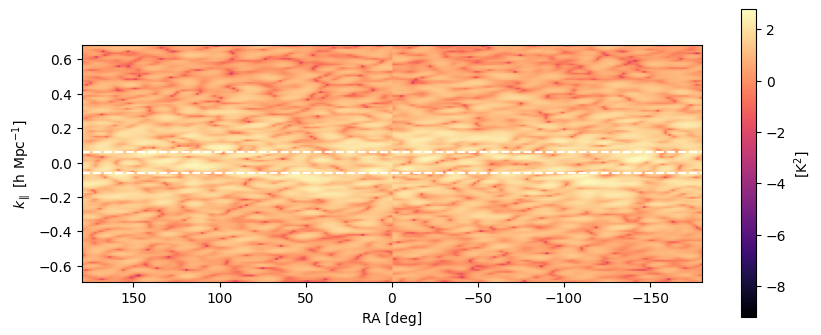

In [32]:
import numpy as np
_ = plot_delay_spectrum(cosmo, bl_ind=ibase)

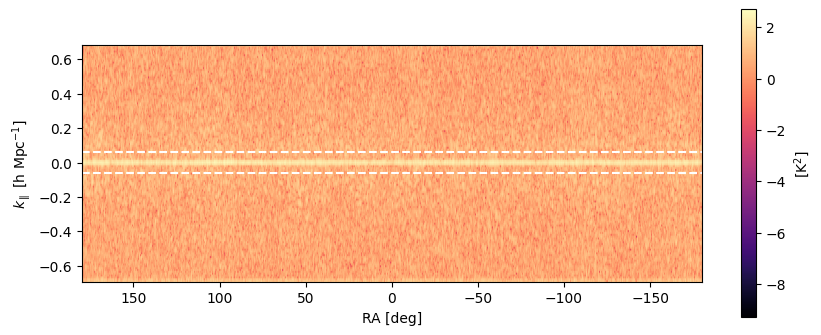

In [33]:
_ = plot_delay_spectrum(net_pred, bl_ind=ibase)

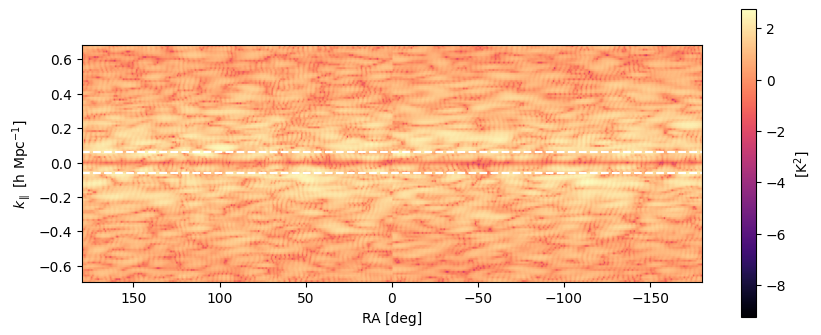

In [34]:
_ = plot_delay_spectrum(pca_pred, bl_ind=ibase)

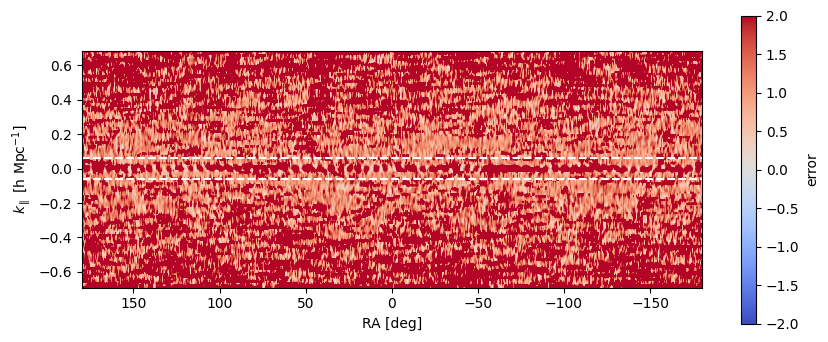

In [35]:
(fig,res_delay_spec_unet) = plot_delay_spectrum_of_residual(net_pred, cosmo, bl_ind=ibase, rel_range=3)

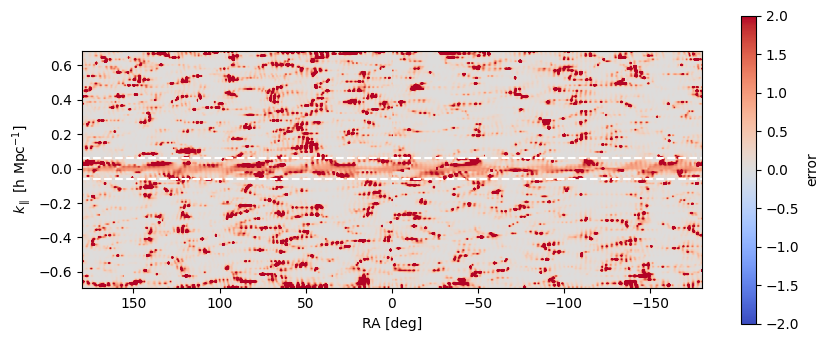

In [36]:
(_, res_delay_spec_pca7) = plot_delay_spectrum_of_residual(pca_pred, cosmo, bl_ind=ibase, rel_range=3)

In [37]:
def delay_spectrum_res_1D(data1, data_true, bl_ind, band_center=550*units.MHz, wedge_angle=90*units.deg, rel_range=12):
    
    delays1, k_par, delay_spec1 = baseline_delay_spectrum(data1, bl_ind, band_center=band_center)
    
    delays2, k_par, delay_spec2 = baseline_delay_spectrum(data_true, bl_ind, band_center=band_center)
    
    delay_spec = (delay_spec1 - delay_spec2) / delay_spec2
    
    ras = np.linspace(180, -180, delay_spec.shape[1] + 1)
    
    return np.mean(delay_spec, -1), k_par

In [38]:
pca7_res_spec,kpar = delay_spectrum_res_1D(pca_pred, cosmo, bl_ind=7)
unet_res_spec,kpar = delay_spectrum_res_1D(net_pred, cosmo, bl_ind=7)

In [39]:
N_FG=11

(-10.0, 10.0)

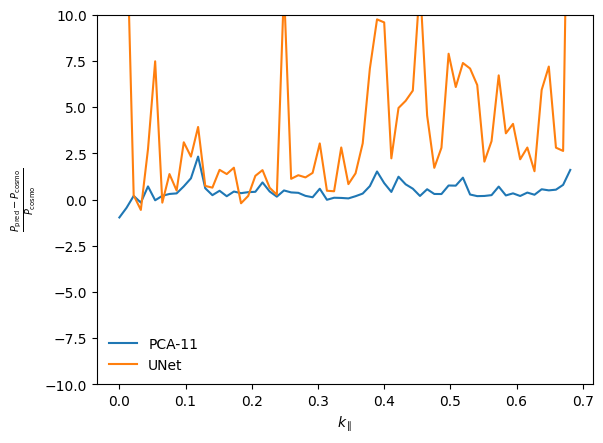

In [40]:
nyquist = 128 // 2

plt.plot(kpar[nyquist:], pca7_res_spec[nyquist:], label="PCA-%d"%(N_FG))
plt.plot(kpar[nyquist:], unet_res_spec[nyquist:], label="UNet")
#plt.yscale('log')
plt.legend(framealpha=0.0)
plt.xlabel(r"$k_\parallel$")
plt.ylabel(r"$\frac{P_{\rm pred} - P_{\rm cosmo}}{P_{\rm cosmo}}$")
plt.ylim(-10, 10)

In [41]:
def residual_delay_spec_1D(data1, data_true, bl_ind, band_center=550*units.MHz, wedge_angle=90*units.deg, rel_range=12):
    
    delays, k_par, delay_spec = baseline_delay_spectrum((data1 - data_true), bl_ind, band_center=band_center)
    
    delays, k_par, delay_spec2 = baseline_delay_spectrum((data_true), bl_ind, band_center=band_center)

    delay_spec /= delay_spec2
    
    ras = np.linspace(180, -180, delay_spec.shape[1] + 1)
    
    return np.mean(delay_spec, -1), k_par

In [352]:
pca7_spec_res,kpar = residual_delay_spec_1D(pca_pred, cosmo, bl_ind=7)
unet_spec_res,kpar = residual_delay_spec_1D(net_pred, cosmo, bl_ind=7)

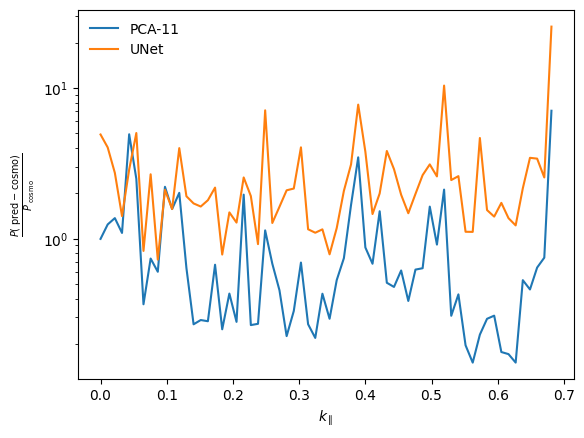

In [353]:
nyquist = 128 // 2

plt.plot(kpar[nyquist:], pca7_spec_res[nyquist:], label='PCA-%d'%(N_FG))
plt.plot(kpar[nyquist:], unet_spec_res[nyquist:], label='UNet')
plt.ylabel(r"$\frac{P({\ \rm pred} - {\rm cosmo})}{P_{\ \rm cosmo}}$")
plt.xlabel(r"$k_\parallel$")
plt.legend(framealpha=0.0)
plt.yscale('log')